# Análise da Qualidade do ar no Brasil


# Contexto do Problema

A poluição do ar é um problema crescente em diversas cidades brasileiras. O Ministério do Meio Ambiente
deseja analisar dados coletados por sensores ambientais instalados em diferentes capitais para entender:

* quais cidades apresentam maior concentração de poluentes
* quais períodos do ano apresentam pior qualidade do ar
* quais poluentes são mais críticos

# Dicionário de dados
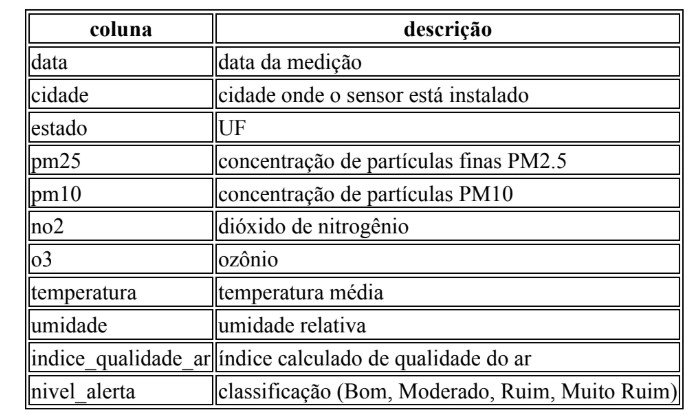


* **7 colunas de medições**
* **10 cidades**
* **4 colunas indicando poluentes atmosféricos(pm25, pm10, no2 e o3)**
* **nenhum valor ausente(dataset tratado e limpado previamente)**


# Importando bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

ar_df = pd.read_csv('qualidade_ar_brasil.csv')

ar_df.head()

,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta
0,2025-01-01,Brasília,DF,33.7,60.9,44.6,31.8,25.5,57.8,61.7,Moderado
1,2025-01-01,Curitiba,PR,25.7,22.1,29.4,40.0,17.1,77.4,43.4,Moderado
2,2025-01-01,Salvador,BA,18.8,27.6,29.2,60.2,29.3,78.0,47.5,Moderado
3,2025-01-02,Curitiba,PR,12.4,41.1,20.0,32.6,20.3,85.7,35.8,Bom
4,2025-01-03,Belo Horizonte,MG,32.0,57.3,36.4,23.5,26.3,74.6,54.1,Moderado


## Inspeção Inicial do dataframe

In [ ]:
ar_df.shape


(800, 11)

In [ ]:
ar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data                 800 non-null    object 
 1   cidade               800 non-null    object 
 2   estado               800 non-null    object 
 3   pm25                 800 non-null    float64
 4   pm10                 800 non-null    float64
 5   no2                  800 non-null    float64
 6   o3                   800 non-null    float64
 7   temperatura          800 non-null    float64
 8   umidade              800 non-null    float64
 9   indice_qualidade_ar  800 non-null    float64
 10  nivel_alerta         800 non-null    object 
dtypes: float64(7), object(4)
memory usage: 68.9+ KB


In [ ]:
ar_df.describe()

,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,26.597625,46.84950,27.537125,32.405125,25.640500,74.918750,47.758375
std,8.983311,13.63357,9.157577,9.247010,4.608675,9.492972,8.747129
min,6.000000,12.20000,5.000000,8.000000,14.500000,47.300000,28.600000
25%,20.400000,37.10000,21.700000,25.400000,22.300000,69.275000,41.600000
50%,25.900000,46.30000,26.800000,32.500000,25.850000,76.250000,46.900000
75%,32.000000,55.10000,32.900000,38.400000,29.100000,81.425000,53.500000
max,60.100000,91.60000,61.700000,68.100000,36.100000,96.000000,86.300000


# Análise Exploratória dos Dados

In [ ]:
ar_df['cidade'].unique() # Cidades presentes na Análise

array(['Brasília', 'Curitiba', 'Salvador', 'Belo Horizonte', 'Recife',
       'Fortaleza', 'Rio de Janeiro', 'Porto Alegre', 'Manaus',
       'São Paulo'], dtype=object)

In [ ]:
poluição_cidades= ar_df.groupby('cidade')[['pm25', 'pm10', 'no2', 'o3']].mean()# Quantidade de poluição total por cidade
poluição_cidades

,pm25,pm10,no2,o3
cidade,,,,
Belo Horizonte,27.874026,48.409091,27.992208,30.141558
Brasília,31.351724,59.428736,29.926437,33.167816
Curitiba,25.339785,43.408602,26.151613,28.435484
Fortaleza,23.186250,44.662500,24.232500,34.176250
Manaus,26.271084,46.898795,22.566265,30.354217
Porto Alegre,26.798592,47.760563,27.959155,27.991549
Recife,23.416471,41.165882,24.320000,32.205882
Rio de Janeiro,27.825301,43.106024,30.925301,38.836145
Salvador,21.503896,39.102597,24.568831,34.274026


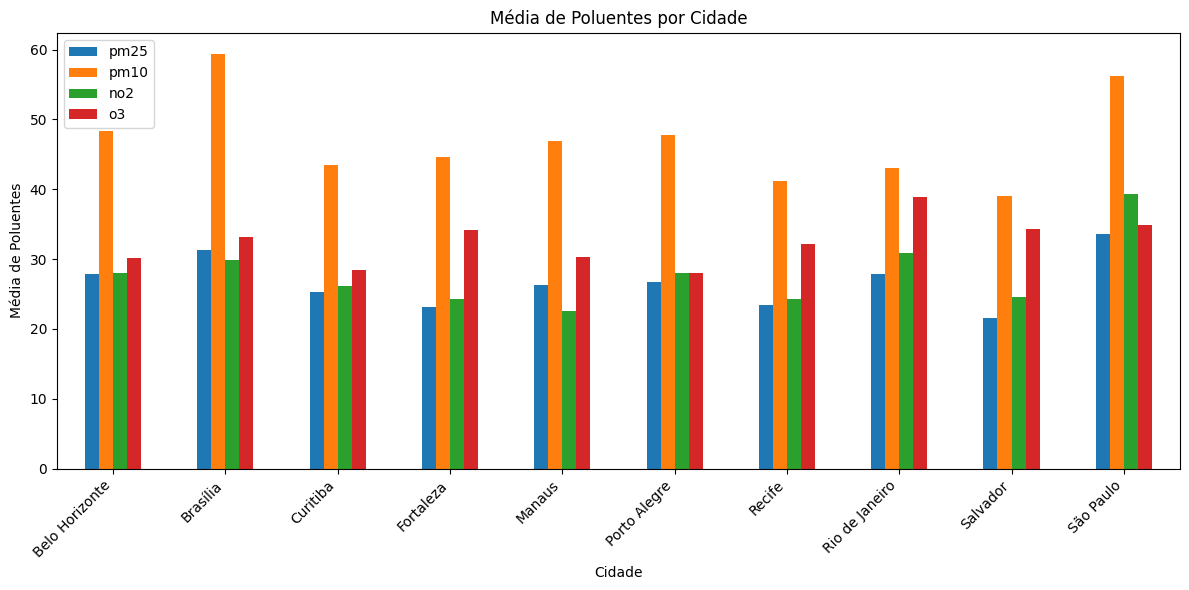

In [ ]:
poluição_cidades.plot(kind='bar', figsize=(12, 6))
plt.title('Média de Poluentes por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Média de Poluentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* **Percebe-se que São Paulo tem a maior quantidade de partículas de ar PM25(Particulas de ar pequenas e mais nocivas à saúde humana). Além disso, a quantidade de dióxido de nitrogêneo(NO2) é muito maior que as demais cidades.**

* **Rio de Janeiro possui a maior quantidade de O3 e também é uma das cidades mais poluentes**

In [ ]:
qualidade_ar = ar_df.groupby('cidade')['indice_qualidade_ar'].mean().sort_values(ascending=False)
qualidade_ar

,indice_qualidade_ar
cidade,
São Paulo,59.345312
Brasília,54.955172
Rio de Janeiro,50.639759
Belo Horizonte,48.344156
Porto Alegre,46.898592
Manaus,45.092771
Fortaleza,44.646250
Curitiba,44.359140
Recife,43.198824


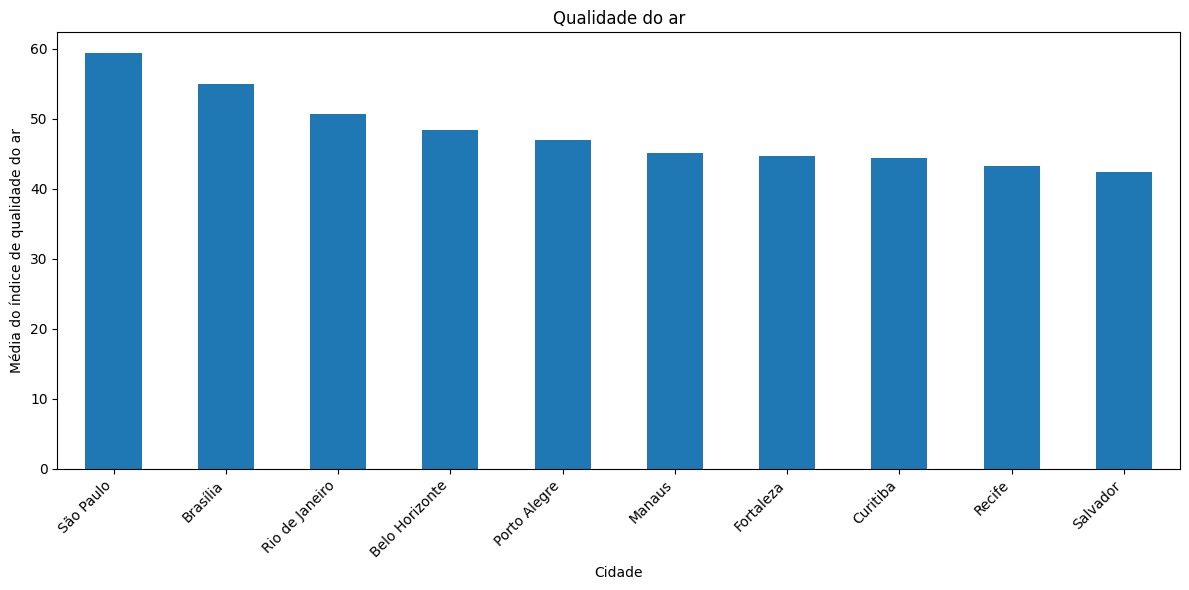

In [ ]:
qualidade_ar.plot(kind='bar', figsize=(12, 6))
plt.title('Qualidade do ar')
plt.xlabel('Cidade')
plt.ylabel('Média do índice de qualidade do ar')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* **Através da análise acima, é possível perceber que São Paulo possui a pior média de qualidade do ar e Salvador possui a melhor.**

**Obs: Quanto maior o índice, pior a qualidade**

In [ ]:
df_alerta = ar_df[ar_df['nivel_alerta'].isin(['Ruim'])]
df_alerta.sort_values(by='indice_qualidade_ar', ascending=False).head(10)

,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta,mes
488,2025-08-19,São Paulo,SP,55.2,78.8,55.0,45.3,20.3,80.3,86.3,Ruim,8
431,2025-07-27,São Paulo,SP,60.1,50.0,56.4,54.8,25.2,76.3,84.3,Ruim,7
410,2025-07-15,São Paulo,SP,42.4,87.6,44.6,40.2,21.2,74.7,76.5,Ruim,7
379,2025-07-03,São Paulo,SP,51.7,78.9,48.3,26.8,21.6,68.0,76.1,Ruim,7
358,2025-06-20,Belo Horizonte,MG,44.5,78.9,41.8,46.1,27.0,64.8,75.9,Ruim,6
548,2025-09-17,Brasília,DF,54.3,69.2,37.4,36.0,23.8,62.5,73.6,Ruim,9
347,2025-06-17,Brasília,DF,52.7,79.1,35.4,31.9,28.6,51.0,73.5,Ruim,6
319,2025-06-01,Rio de Janeiro,RJ,45.1,70.1,37.4,48.0,28.1,78.9,72.7,Ruim,6
411,2025-07-15,São Paulo,SP,35.8,91.6,41.6,36.7,22.4,79.9,71.8,Ruim,7
320,2025-06-02,Manaus,AM,53.6,79.5,25.2,36.2,31.7,74.9,71.6,Ruim,6


* Acima, é possível perceber que São Paulo possui a maior frequência de índices de alerta. Ordenando os dados pelo índice de qualidade do ar, conclui-se que é uma situação crítica e que precisa ser resolvida com urgência.
Rio e Brasília também são duas cidades que precisam de atenção

In [ ]:
ar_df['data'] = pd.to_datetime(ar_df['data'])
ar_df['mes'] = ar_df['data'].dt.month
ar_df.groupby('mes')['indice_qualidade_ar'].mean()

,indice_qualidade_ar
mes,
1,44.852308
2,42.985714
3,46.675949
4,47.559259
5,47.107813
6,52.881034
7,51.293443
8,49.640000
9,49.923333


* Os piores índices de qualidade do ar ocorrem nos meses de junho a setembro, devido à secas, alta taxa de incêndios e baixa umidade no país.

#Correlações entre variáveis

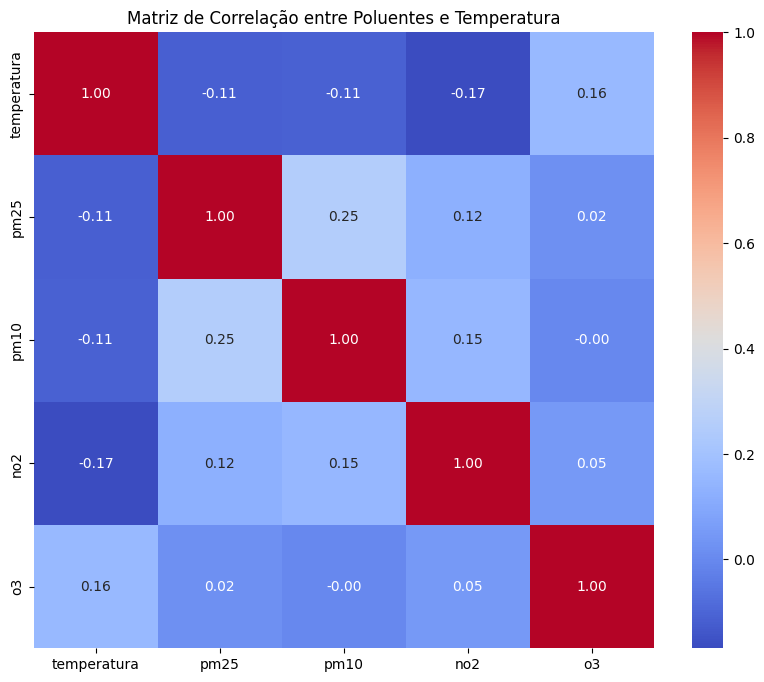

In [ ]:
correlation_matrix = ar_df[['temperatura', 'pm25', 'pm10', 'no2', 'o3']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Poluentes e Temperatura')
plt.show()

* **De acordo com a matrix de correlação, a correlação entre temperatura e os poluentes é muito fraca. Isso indica que pode haver índices de poluição altos, independentemente da temperatura do local. A melhor relação está na presença de O3. Quanto mais quente o local, maior formação dos gases de ozônio(O3).**

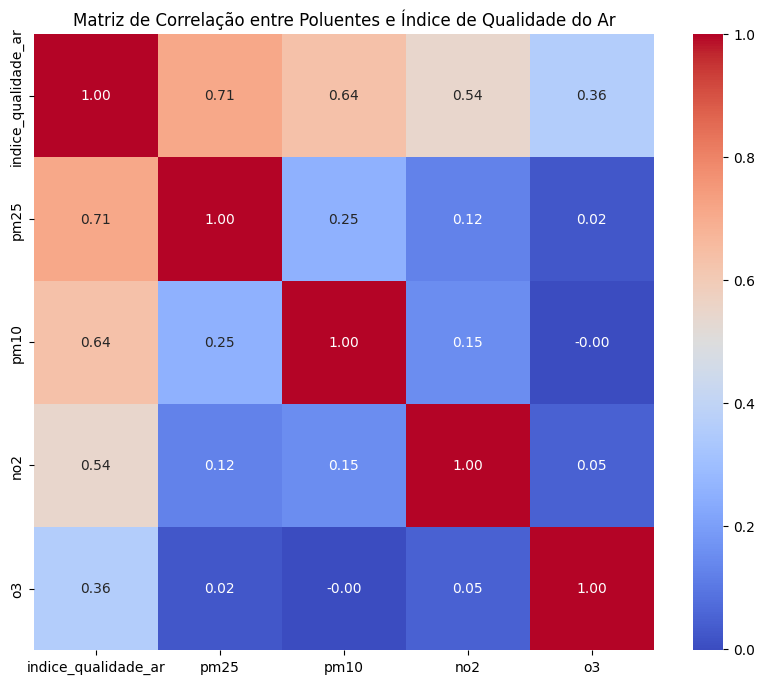

In [ ]:
poluicao_matrix = ar_df[['indice_qualidade_ar','pm25', 'pm10', 'no2', 'o3',]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(poluicao_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Poluentes e Índice de Qualidade do Ar')
plt.show()

* **A correlação entre as variáveis de poluentes e de indice de qualidade do ar, mostra que há uma relação alta entre a presença de partículas pm25 e pm10 e o índice de qualidade do ar. Ou seja, quanto mais presença delas, mais o ambiente será nocivo, principalmente o pm25**

# Relatório Final e Conclusão da análise

### Por fim, conclui-se que é necessário um cuidado especial com o Meio Ambiente no Brasil e que medidas devem ser tomadas para que não haja uma piora ainda maior nos índices de qualidade do ar e na presença dos gases poluentes.


### De acordo com todas as análises feitas nesse documento, é possível destacar os principais resultados:

 * **São Paulo é a cidade com maior taxa de poluição e e a pior qualidade do ar, sendo destacada com alertas de nível "Ruim" nos períodos de Junho - Setembro(Meses em que o índice de qualidade do ar está pior, devido à humidade baixa e índice de queimadas em todo o Brasil). É preciso que soluções sejam tomadas para diminuir as causas de poluição na cidade de São Paulo, em níveis de meio ambiente, indústria e transporte.**


* **As partículas de ar pm25 e pm10 são os piores poluentes apresentados nessa pesquisa e estão altamente relacionados com a qualidade do ar. São Paulo, Rio de Janeiro e Brasília são as cidades com mais presença deles e que precisam da atenção imediata do Ministério da Saúde**



